App EU to EU
{'avg': np.float64(18.884036000000002),
 'max': np.float64(1723.835),
 'median': np.float64(16.857),
 'std': np.float64(54.005889140598086)}

App EU to US
{'avg': np.float64(121.43058599999999),
 'max': np.float64(1901.134),
 'median': np.float64(119.40350000000001),
 'std': np.float64(56.362344297760934)}

App US to US
{'avg': np.float64(15.17106),
 'max': np.float64(915.609),
 'median': np.float64(13.998000000000001),
 'std': np.float64(28.65197171996793)}

App US to EU
{'avg': np.float64(135.26486799999998),
 'max': np.float64(1641.825),
 'median': np.float64(133.585),
 'std': np.float64(47.72967969557745)}

Vanilla EU
{'avg': np.float64(54.343115),
 'max': np.float64(2079.853),
 'median': np.float64(16.573999999999998),
 'std': np.float64(102.89243648468789)}

Vanilla US
{'avg': np.float64(83.16157799999999),
 'max': np.float64(188.674),
 'median': np.float64(120.71799999999999),
 'std': np.float64(51.41482425407086)}



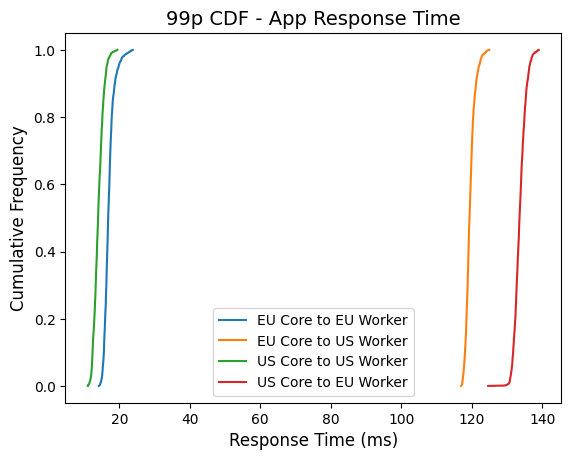

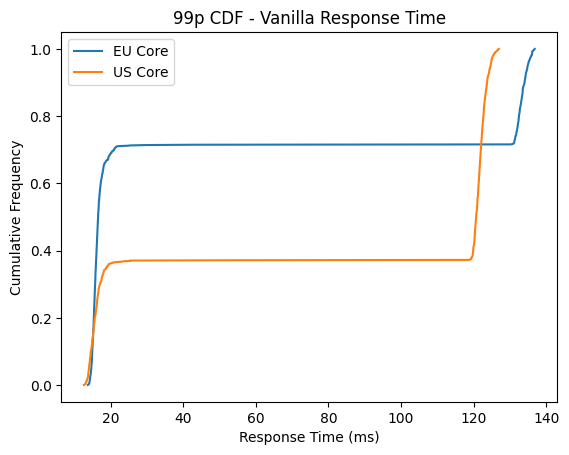

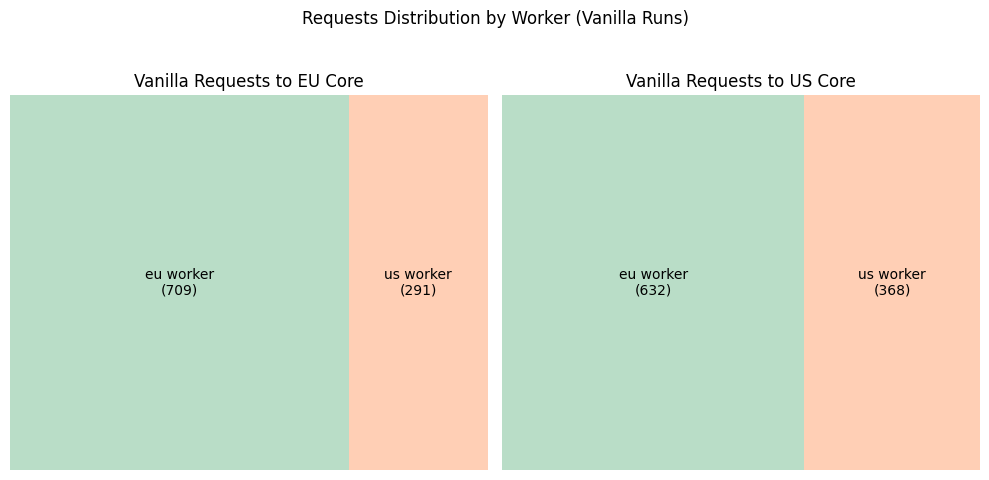

In [ ]:
import pandas as pd
import pprint
import matplotlib.pyplot as plt
import numpy as np
import squarify

def calculate_stats(rt):
    avg = rt.mean()
    median = rt.median()
    std = rt.std()
    max = rt.max()
    return {"avg": avg, "median": median, "std": std, "max": max}

# Read the CSV files
requests_app_eu_to_eu = pd.read_csv('app/from_eu/to_eu/merged_from_eu.csv')
requests_app_eu_to_us = pd.read_csv('app/from_eu/to_us/merged_from_eu_to_us.csv')
requests_app_us_to_us = pd.read_csv('app/from_us/to_us/merged_from_us.csv')
requests_app_us_to_eu = pd.read_csv('app/from_us/to_eu/merged_from_us_to_eu.csv')

requests_vanilla_eu = pd.read_csv('vanilla/from_eu/merged_vanilla_from_eu.csv')
requests_vanilla_us = pd.read_csv('vanilla/from_us/merged_vanilla_from_us.csv')

# Extract the response_time column
app_eu_to_eu_response_time = requests_app_eu_to_eu['Response Time (ms)']
app_eu_to_us_response_time = requests_app_eu_to_us['Response Time (ms)']
app_us_to_us_response_time = requests_app_us_to_us['Response Time (ms)']
app_us_to_eu_response_time = requests_app_us_to_eu['Response Time (ms)']

vanilla_eu_response_time = requests_vanilla_eu['Response Time (ms)']
vanilla_us_response_time = requests_vanilla_us['Response Time (ms)']

# Calculate statistics
app_eu_to_eu_stats = calculate_stats(app_eu_to_eu_response_time)
app_eu_to_us_stats = calculate_stats(app_eu_to_us_response_time)
app_us_to_us_stats = calculate_stats(app_us_to_us_response_time)
app_us_to_eu_stats = calculate_stats(app_us_to_eu_response_time)

vanilla_eu_stats = calculate_stats(vanilla_eu_response_time)
vanilla_us_stats = calculate_stats(vanilla_us_response_time)

print("App EU to EU")
pprint.pprint(app_eu_to_eu_stats)
print()
print("App EU to US")
pprint.pprint(app_eu_to_us_stats)
print()
print("App US to US")
pprint.pprint(app_us_to_us_stats)
print()
print("App US to EU")
pprint.pprint(app_us_to_eu_stats)
print()
print("Vanilla EU")
pprint.pprint(vanilla_eu_stats)
print()
print("Vanilla US")
pprint.pprint(vanilla_us_stats)
print()

# Plot the datasets

def plot_cdf_best_99(data, label):
    # Compute the 99th percentile threshold (i.e., worst 1% gets dropped)
    threshold = np.percentile(data, 99)
    # Filter the data: keep only the best 99%
    filtered_data = np.array(data)[np.array(data) < threshold]
    # Sort the filtered data
    sorted_data = np.sort(filtered_data)
    # Compute the CDF values (0 to 1)
    cdf = np.arange(1, len(sorted_data)+1) / len(sorted_data)
    plt.plot(sorted_data, cdf, label=label)

# Plot for App Response Time datasets
plt.figure()
plot_cdf_best_99(app_eu_to_eu_response_time, 'EU Core to EU Worker')
plot_cdf_best_99(app_eu_to_us_response_time, 'EU Core to US Worker')
plot_cdf_best_99(app_us_to_us_response_time, 'US Core to US Worker')
plot_cdf_best_99(app_us_to_eu_response_time, 'US Core to EU Worker')
plt.xlabel('Response Time (ms)', fontsize=12)
plt.ylabel('Cumulative Frequency', fontsize=12)
plt.title('99p CDF - App Response Time' , fontsize=14)
plt.legend(fontsize=10)
plt.savefig('CDFApp.pdf')
plt.show()

# Plot for Vanilla Response Time datasets
plt.figure()
plot_cdf_best_99(vanilla_eu_response_time, 'EU Core')
plot_cdf_best_99(vanilla_us_response_time, 'US Core')
plt.xlabel('Response Time (ms)', fontsize=12)
plt.ylabel('Cumulative Frequency', fontsize=12)
plt.title('99p CDF - Vanilla Response Time', fontsize=14)
plt.legend(fontsize=10)
plt.savefig('CDFVanilla.pdf')
plt.show()


import seaborn as sns

# Extract worker columns from each DataFrame
workers_app_eu_to_eu = requests_app_eu_to_eu['Worker']
workers_app_eu_to_us = requests_app_eu_to_us['Worker']
workers_app_us_to_us = requests_app_us_to_us['Worker']
workers_app_us_to_eu = requests_app_us_to_eu['Worker']


# Combine the worker columns with a source indicator from your vanilla DataFrames
workers_vanilla_df = pd.concat([
    requests_vanilla_eu[['Worker']].assign(Source='Vanilla Requests to EU Core'),
    requests_vanilla_us[['Worker']].assign(Source='Vanilla Requests to US Core')
])

# Get unique sources for vanilla endpoints
sources = workers_vanilla_df['Source'].unique()
n_sources = len(sources)

# Set up subplots, one per source
fig, axes = plt.subplots(1, n_sources, figsize=(5 * n_sources, 5))
if n_sources == 1:
    axes = [axes]

# Define a mapping dictionary from raw worker names to your preferred labels
label_mapping = {
    'worker@10.128.0.2': 'eu worker',
    'worker@10.128.16.3': 'us worker'
}

# Define a color mapping so that eu worker and us worker always get the same color
color_mapping = {
    'eu worker': '#A8D5BA',  # Pastel green
    'us worker': '#FFC4A3'   # Pastel orange
}
default_color = 'grey'

for ax, source in zip(axes, sources):
    # Filter data for the current source
    source_data = workers_vanilla_df[workers_vanilla_df['Source'] == source]
    count_data = source_data['Worker'].value_counts()
    
    # Prepare labels and sizes for the treemap
    labels = count_data.index.tolist()
    # Map the raw worker names to the preferred labels
    labels = [label_mapping.get(label, label) for label in labels]
    
    sizes = count_data.values
    label_text = [f"{worker}\n({count})" for worker, count in zip(labels, sizes)]
    
    # Create a list of colors based on the label mapping
    colors = [color_mapping.get(worker, default_color) for worker in labels]
    
    # Plot the treemap with fixed colors
    squarify.plot(sizes=sizes, label=label_text, ax=ax, alpha=0.8, color=colors)
    ax.set_title(source)
    ax.axis('off')

plt.suptitle('Requests Distribution by Worker (Vanilla Runs)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('WorkersDistributionVanilla.pdf')
plt.show()